In [6]:
# build large-scale data in scBank format from a group of AnnData objects
# %%
import gc
import json
from pathlib import Path
import argparse
import shutil
import traceback
from typing import Dict, List, Optional
import warnings
import numpy as np
import os
import anndata

import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from typing import Any, Dict, List, Mapping, Optional, Tuple, Union
from typing_extensions import Self, Literal
from scipy.sparse import issparse

import matplotlib as mpl
def set_vis_default(font = 1.6, circle_marker = 1.):
    mpl.rcParams['font.family'] = 'Arial'
    plt.rcParams.update(plt.rcParamsDefault)
#     %matplotlib inline
    try:
        plt.style.use('seaborn-whitegrid')
    except:
        plt.style.use('seaborn-v0_8-whitegrid')

    sns.set_context('paper',font_scale=font)
    plt.rcParams["legend.markerscale"] = circle_marker
    mpl.rcParams['font.family'] = 'Arial'



In [3]:
base_path = '/import/home2/xwanaf/Img2Expr/data/Reproducibility_data/PF'
file_path = Path(base_path)

file_name = 'UGE_atlas.h5ad'
atlas_adata = sc.read(file_path / file_name)
atlas_adata

AnnData object with n_obs × n_vars = 946364 × 1741
    obs: 'cell_type', 'cell_id', 'dataset_idx', 'dataset_cell_id', 'ann_finest_level', 'dataset', 'ann_level_1', 'disease', 'original_ann_nonharmonized', 'leiden_2p0', 'leiden_2p5', 'leiden_1p5', 'leiden_0p5', 'leiden_1p0', 'leiden_0p5_ct_v0', 'leiden_1p0_ct_v0', 'leiden_2p5_ct_v0', 'tmp', 'leiden_2p5_epi_v1', 'leiden_2p5_epi', 'leiden_2p5_epi_v2', 'leiden_2p5_epi_v3', 'leiden_2p5_epi_v7', 'leiden_2p5_epi_v4', 'leiden_1p_fibro_v1', 'ct_anno'
    uns: 'ann_finest_level_colors', 'dataset_colors', 'disease_colors', 'leiden_2p0_colors', 'leiden_2p5_colors', 'leiden_2p5_ct_v0_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

# Cell type annotation

In [4]:
color_dict = {'AT1': '#ffff00',
 'AT2': '#1ce6ff',
 'Aberrant Basaloid': '#ff34ff',
 'Alveolar Mph CCL3+': '#ff4a46',
 'Alveolar Mph proliferating': '#008941',
 'Alveolar macrophages': '#006fa6',
 'B cells': '#a30059',
 'Basal': '#ffdbe5',
 'Basal-Prolif': '#7a4900',
 'CD4 T cells': '#0000a6',
 'CD8 T cells': '#63ffac',
 'Ciliated': '#b79762',
 'Ciliated MUC5AC+': '#004d43',
 'Ciliated SCGB3A2+': '#8fb0ff',
 'Classical monocytes': '#997d87',
 'DC1': '#5a0007',
 'DC2': '#809693',
 'EC aerocyte capillary': '#6a3a4c',
 'EC arterial': '#1b4400',
 'EC general capillary': '#4fc601',
 'EC venous systemic': '#3b5dff',
 'FB': '#4a3b53',
 'FB COL1A1+': '#ff2f80',
 'FB ECM': '#61615a',
 'FB ECM CHI3L2+': '#ba0900',
 'FB ECM COL1A1+': '#6b7900',
 'FB ECM SOX4+': '#00c2a0',
 'FB HAS1+': '#ffaa92',
 'Interstitial Mph perivascular': '#ff90c9',
 'Ionocyte': '#b903aa',
 'Lymphatic EC mature': '#d16100',
 'Mast cells': '#ddefff',
 'Mesothelial': '#000035',
 'Migratory DCs': '#7b4f4b',
 'Monocyte-derived Mph': '#a1c299',
 'NK cells': '#300018',
 'Neuroendocrine': '#0aa6d8',
 'Non-classical monocytes': '#013349',
 'Pericytes': '#00846f',
 'Plasma cells': '#372101',
 'Plasmacytoid DCs': '#ffb500',
 'SCGB1A1+/SCGB3A1+/SCGB3A2+': '#c2ffed',
 'SCGB3A1+/SCGB3A2+': '#a079bf',
 'SMCs': '#cc0744',
 'SMG duct': '#c0b9b2',
 'SMG-Serous': '#c2ff99',
 'Secretory MUC5AC+': '#001e09',
 'Secretory MUC5B+': '#00489c',
 'Smooth muscle': '#6f0062',
 'Squamous': '#0cbd66',
 'Suprabasal': '#eec3ff',
 'Suprabasal SCGB1A1+': '#456d75',
 'myo-FB': '#b77b68'}

In [18]:
# import pickle
# with open('color_dict.pkl', 'wb') as file:  # Use 'wb' to open the file in write-binary mode
#     pickle.dump(color_dict, file)
# # with open('color_dict.pkl', 'rb') as file:  # Use 'rb' to open the file in read-binary mode
# #     color_dict = pickle.load(file)


/tmp/ipykernel_3444589/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')
/home/xwanaf/.conda/envs/scGPT/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


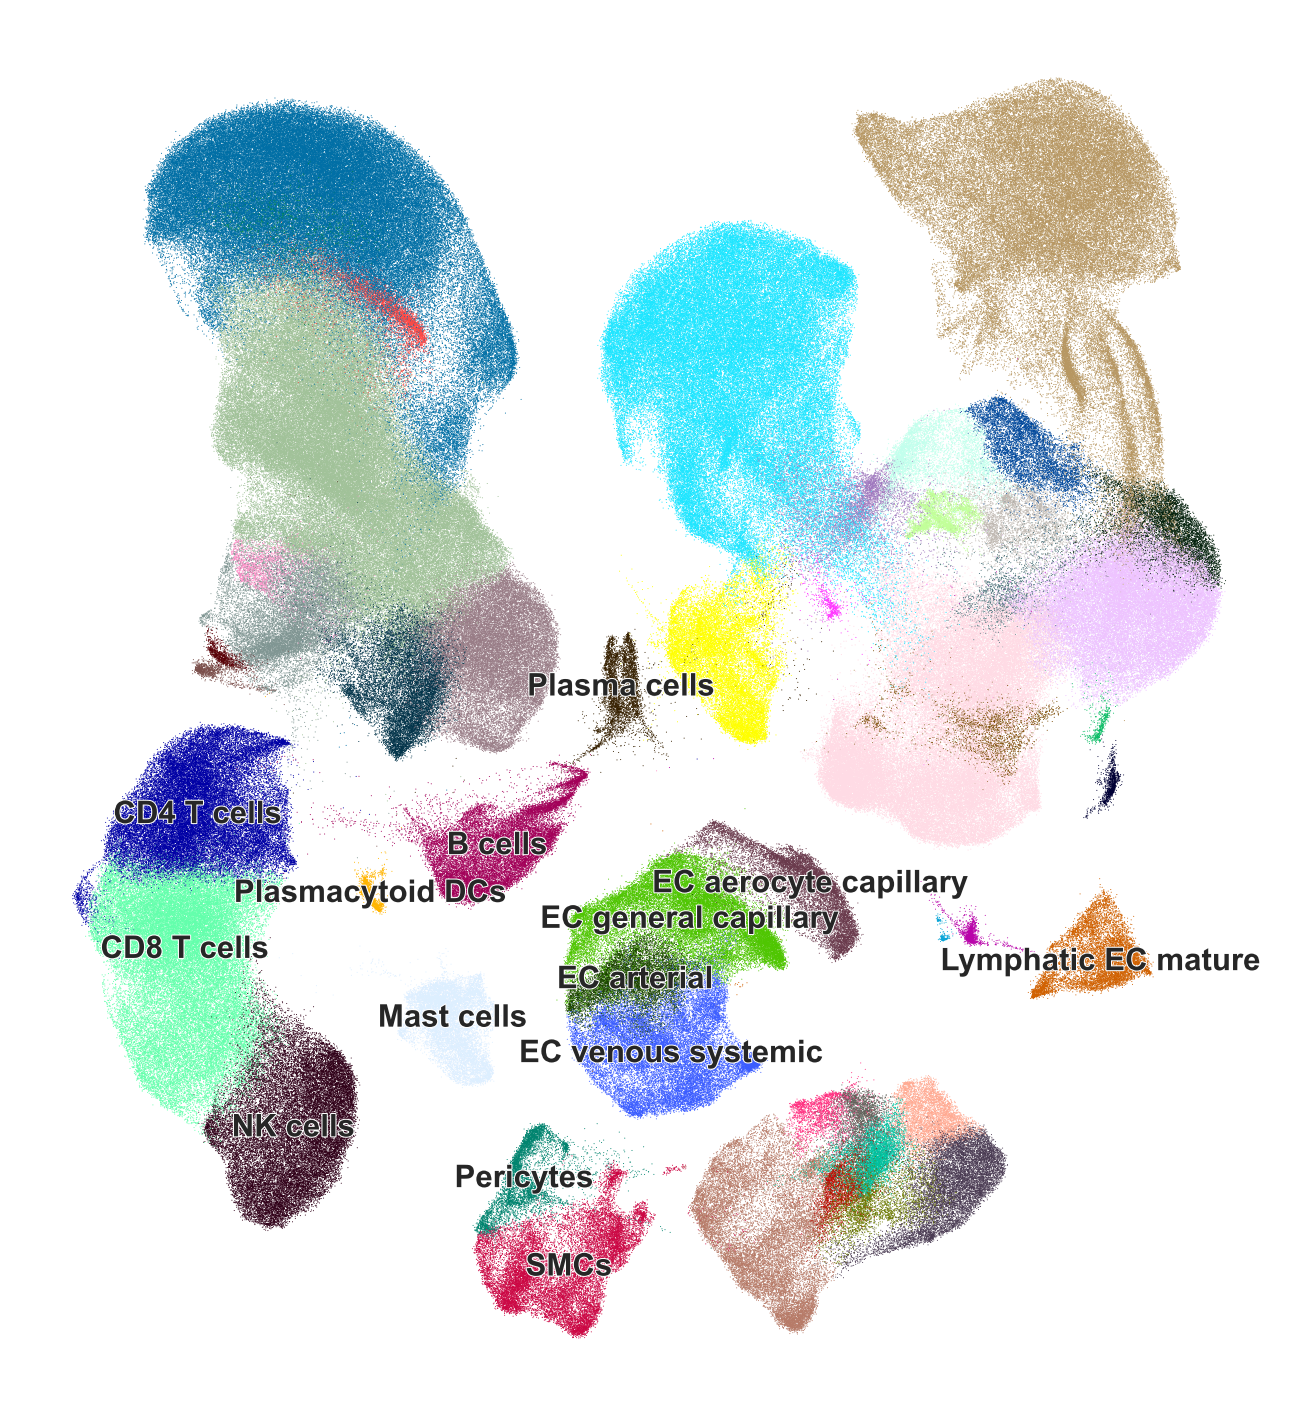

In [8]:
import matplotlib.patheffects as path_effects
set_vis_default(font = .8, circle_marker = 3.)

# ct_all = adata_all.obs['dataset_names'].astype('category').unique().categories

adata_vis = atlas_adata

fig, axs = plt.subplots(1, 2, figsize=(24, 12), dpi = 150, gridspec_kw={'wspace': .2, 'hspace': 0.05})

sc.pl.umap(
    adata_vis, color='ct_anno', 
    size=1, frameon=False, show=False, ax=axs[0], 
    palette = color_dict, 
#     groups = groups#,
    legend_loc = None #'on data' 
)
# axs[0].legend(bbox_to_anchor=(1., 1.0))
axs[0].set_title('')

label_cts = [
    'NK cells',
 'CD4 T cells',
 'CD8 T cells',
 'Mast cells',
 'B cells',
 'Plasma cells',
 'Plasmacytoid DCs',
    
    'Lymphatic EC mature',
 'EC arterial',
 'EC venous systemic',
 'EC aerocyte capillary',
 'EC general capillary',
    
    'Pericytes',
 'SMCs',
    
]

indices_to_label = adata_vis.obs.index[adata_vis.obs['ct_anno'].isin(label_cts)].tolist()

# Loop through the indices and add labels
for ct in label_cts:
    index = adata_vis.obs['ct_anno'].isin([ct])
    # Get the UMAP coordinates
    x = adata_vis.obsm['X_umap'][index, 0]
    y = adata_vis.obsm['X_umap'][index, 1]
    x_mid, y_mid = np.median(x), np.median(y)

    # Add label (replace 'Label' with your desired label)
    axs[0].text(
        x_mid, y_mid, ct, fontsize=15, 
        ha='center', va='center', 
        fontweight = 'bold', 
        path_effects=[path_effects.withStroke(linewidth=1, foreground='white')]
    )

axs[1].remove()


plt.show()
plt.close()

# Disease

/tmp/ipykernel_3444589/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')
/home/xwanaf/.conda/envs/scGPT/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


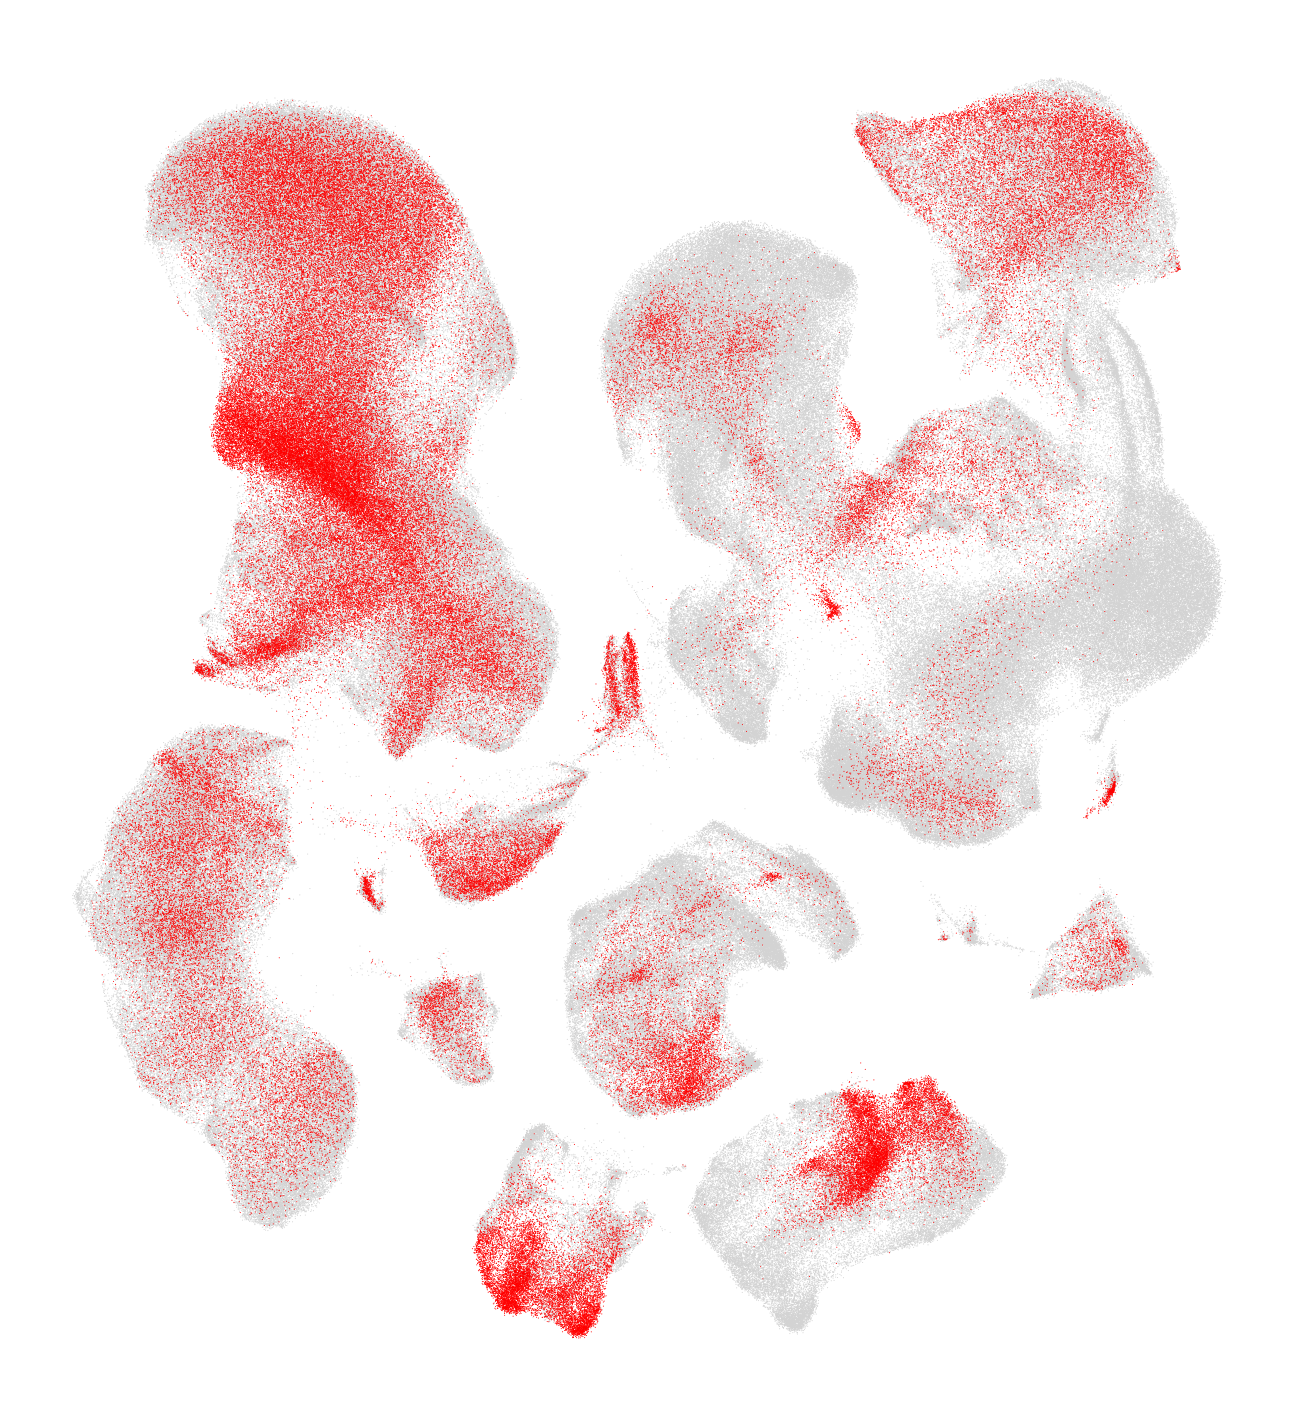

In [9]:
import matplotlib.patheffects as path_effects
set_vis_default(font = .8, circle_marker = 3.)

adata_vis = atlas_adata


fig, axs = plt.subplots(1, 2, figsize=(24, 12), dpi = 150, gridspec_kw={'wspace': .2, 'hspace': 0.05})

color_dict_disease = {
    'pulmonary fibrosis': 'red',
    'normal': 'lightgray'
}
groups = ['pulmonary fibrosis']
sc.pl.umap(
    adata_vis, color='disease', 
    size=1, frameon=False, show=False, ax=axs[0], 
    palette = color_dict_disease, 
    groups = groups,
    legend_loc = None #'on data' 
)
# axs[0].legend(bbox_to_anchor=(1., 1.0))
axs[0].set_title('')


axs[1].remove()


plt.show()
plt.close()

# Studies and samples

In [10]:
base_path = '/import/home2/xwanaf/Img2Expr/data/Reproducibility_data/PF'
file_path = Path(base_path)

obs_concat = pd.read_csv(file_path / 'obs_concat.csv', index_col = 0)

/tmp/ipykernel_3444589/1221211036.py:4: DtypeWarning: Columns (13,16,18,25,28,31,32,33,34,35,36,38,39,40,41,42,44,45,46,47,48,49,52,54,56,58,60) have mixed types. Specify dtype option on import or set low_memory=False.
  obs_concat = pd.read_csv(file_path / 'obs_concat.csv', index_col = 0)


In [15]:
obs_concat['sample'].value_counts()

sample
SC144          23032
distal 2       18541
distal 3       16898
VUILD59        15141
NP32-NB        12616
               ...  
WSSS8123924       50
F01506            47
7119452           45
NP20-TB           37
F01869             8
Name: count, Length: 485, dtype: int64

In [16]:
value_counts = obs_concat.groupby('sample')['disease'].value_counts().unstack(fill_value=0)
print((value_counts.min(1) > 0).sum()) # assert one sample only map one disease state
max_disease = value_counts.idxmax(axis=1)
max_disease.value_counts()

0


normal                414
pulmonary fibrosis     71
Name: count, dtype: int64

In [17]:
obs_concat['study'].value_counts()

study
Kaminski_2020             239707
Banovich_Kropski_2020     179562
Meyer_2021                129125
Meyer_Nikolic_2022        119634
Barbry_Leroy_2020          74487
Nawijn_2021                70402
Misharin_2021              64843
Sheppard_2020              61603
Krasnow_2020               60982
Misharin_Budinger_2018     56737
Duong_lungMAP_unpubl       53904
Sun_2020                   46500
Jain_Misharin_2021         45557
Eils_2020                  39778
Schiller_2020              38598
Schiller_2021              35915
Meyer_2019                 35554
Seibold_2020               33593
Lafyatis_Rojas_2019        24181
Tata_unpubl                21700
Teichmann_Meyer_2019       12231
Peer_Massague_2020         11055
Gomperts_2021              11037
Schultze_unpubl             8016
Shalek_2018                 7603
Name: count, dtype: int64

# Aberrant Basaloid

In [11]:
tmp = np.empty(atlas_adata.shape[0], dtype = object)
index = atlas_adata.obs['ct_anno'].isin(['Aberrant Basaloid'])
tmp[index] = obs_concat.loc[atlas_adata[index].obs.index]['study'].tolist()
value_counts = pd.Series(tmp).value_counts()
sl_dataset = value_counts[value_counts > 50].index.tolist()
index = ~obs_concat.loc[atlas_adata.obs.index]['study'].isin(sl_dataset)
tmp[index] = np.nan
atlas_adata.obs['AB_study'] = tmp
atlas_adata.obs['AB_study'] = atlas_adata.obs['AB_study'].astype('category')

atlas_adata.obs['AB_study'].value_counts()

AB_study
Banovich_Kropski_2020    281
Kaminski_2020            237
Name: count, dtype: int64

/tmp/ipykernel_3444589/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')
/home/xwanaf/.conda/envs/scGPT/lib/python3.8/site-packages/scanpy/plotting/_utils.py:431: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/home/xwanaf/.conda/envs/scGPT/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


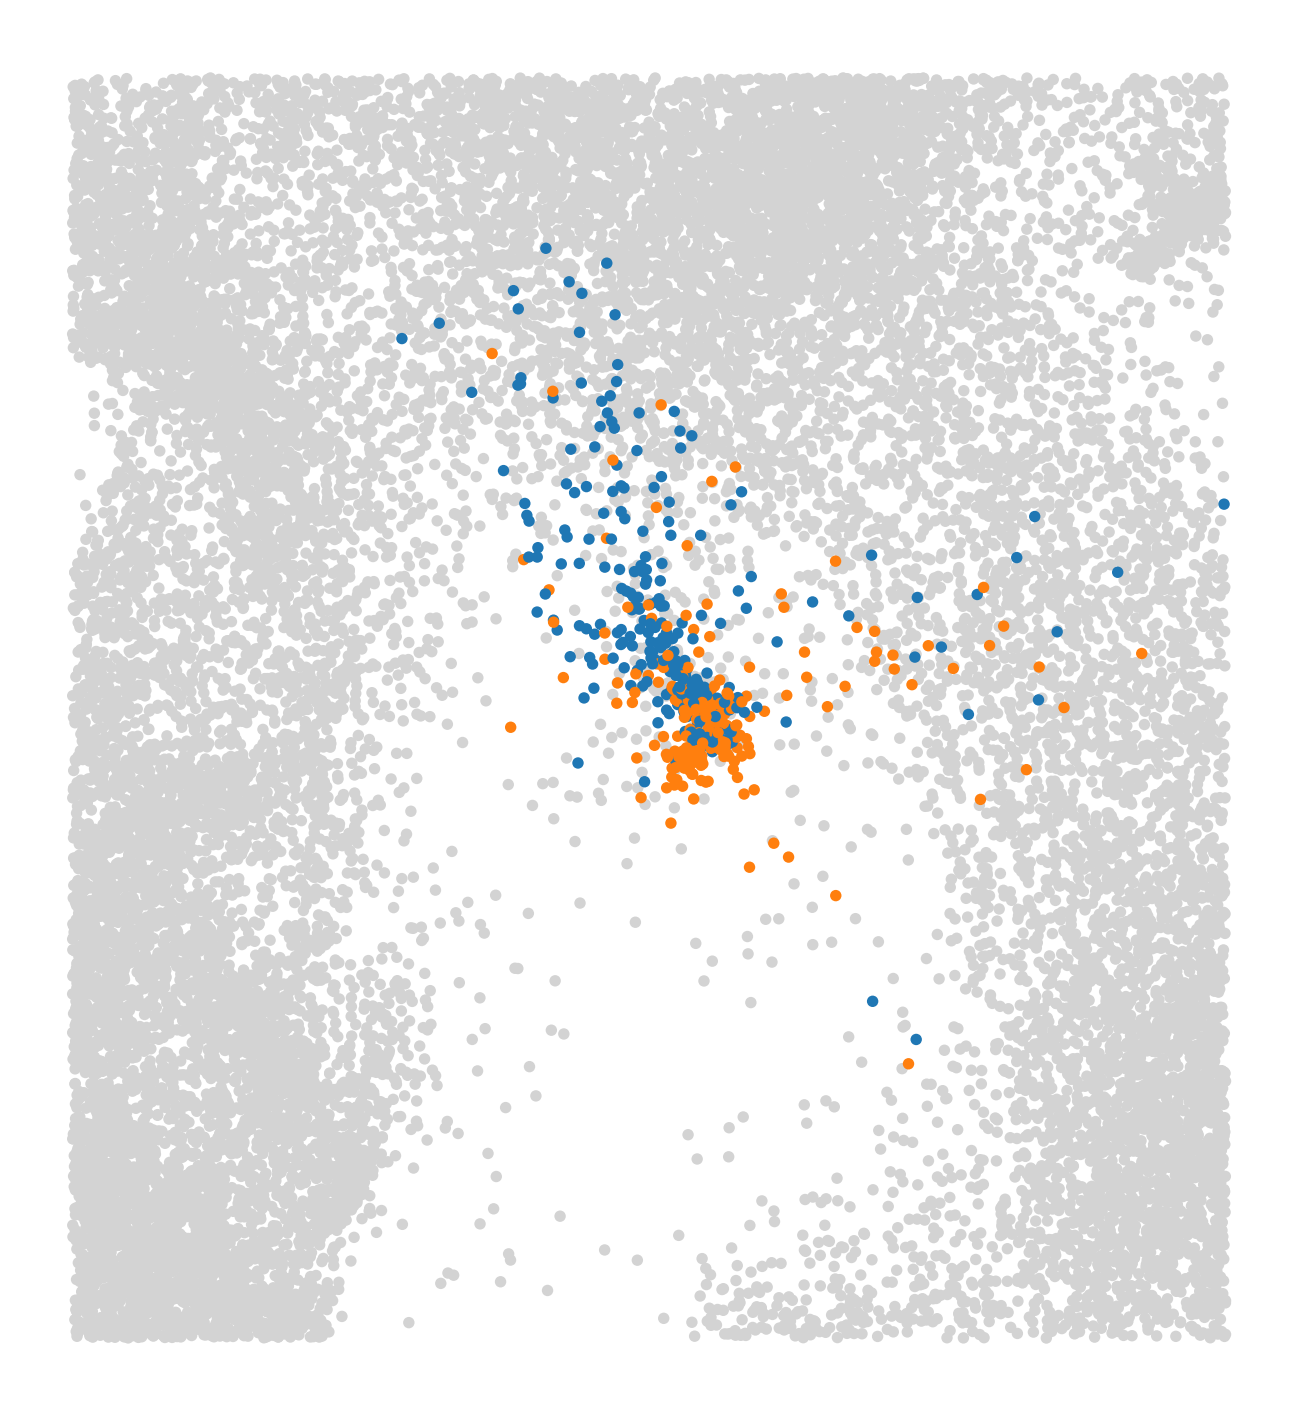

In [12]:
import matplotlib.patheffects as path_effects
set_vis_default(font = .8, circle_marker = 3.)


cond1 = (atlas_adata.obsm['X_umap'][:, 0] >= 6.5) & (atlas_adata.obsm['X_umap'][:, 0] < 10.5)
cond2 = (atlas_adata.obsm['X_umap'][:, 1] >= 5.5) & (atlas_adata.obsm['X_umap'][:, 1] < 9.5)
cond = cond1 & cond2
adata_vis = atlas_adata[cond]


fig, axs = plt.subplots(1, 2, figsize=(24, 12), dpi = 150, gridspec_kw={'wspace': .2, 'hspace': 0.05})

sc.pl.umap(
    adata_vis, color='AB_study', 
    size=120, frameon=False, show=False, ax=axs[0], 
#     palette = color_dict_disease, 
#     groups = groups,
    legend_loc = None #'on data' 
)
# axs[0].legend(bbox_to_anchor=(1., 1.0))
axs[0].set_title('')


axs[1].remove()

plt.show()
plt.close()

In [13]:
myeloid_cts = [
 'Interstitial Mph perivascular',
 'DC2',
 'DC1',
 'Migratory DCs',
 'Classical monocytes',
 'Non-classical monocytes',
 'Monocyte-derived Mph',
 'Alveolar Mph CCL3+',
 'Alveolar macrophages',
]
myeloid_cts_maps = {
    'Interstitial Mph perivascular': f'Interstitial Mph \n perivascular',
 'DC2': 'DC2',
 'DC1': 'DC1',
 'Migratory DCs': 'Migratory DCs',
 'Classical monocytes': 'Classical monocytes',
 'Non-classical monocytes': f'Non-classical \n monocytes',
 'Monocyte-derived Mph': 'Monocyte-derived Mph',
 'Alveolar Mph CCL3+': 'Alveolar Mph CCL3+',
 'Alveolar macrophages': 'Alveolar macrophages',
}
fibroblast_cts = [
    'myo-FB',
 'FB COL1A1+',
 'FB ECM',
 'FB ECM CHI3L2+',
 'FB ECM COL1A1+',
 'FB ECM SOX4+',
 'FB',
 'FB HAS1+',
]
epi_cts = [
    'AT2',
 'SCGB3A1+/SCGB3A2+',
 'AT1',
 'Aberrant Basaloid',
 'Ciliated',
 'Squamous',
 'Basal',
 'Basal-Prolif',
 'SCGB1A1+/SCGB3A1+/SCGB3A2+',
 'Secretory MUC5B+',
 'SMG duct',
 'SMG-Serous',
 'Ionocyte',
 'Neuroendocrine',
 'Suprabasal SCGB1A1+',
 'Secretory MUC5AC+',
 'Suprabasal',
    'Mesothelial'
]
ct_all = [myeloid_cts, fibroblast_cts, epi_cts]
group_titles = ['Myeloid', 'Fibroblast', 'Epithelial']

/tmp/ipykernel_3444589/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


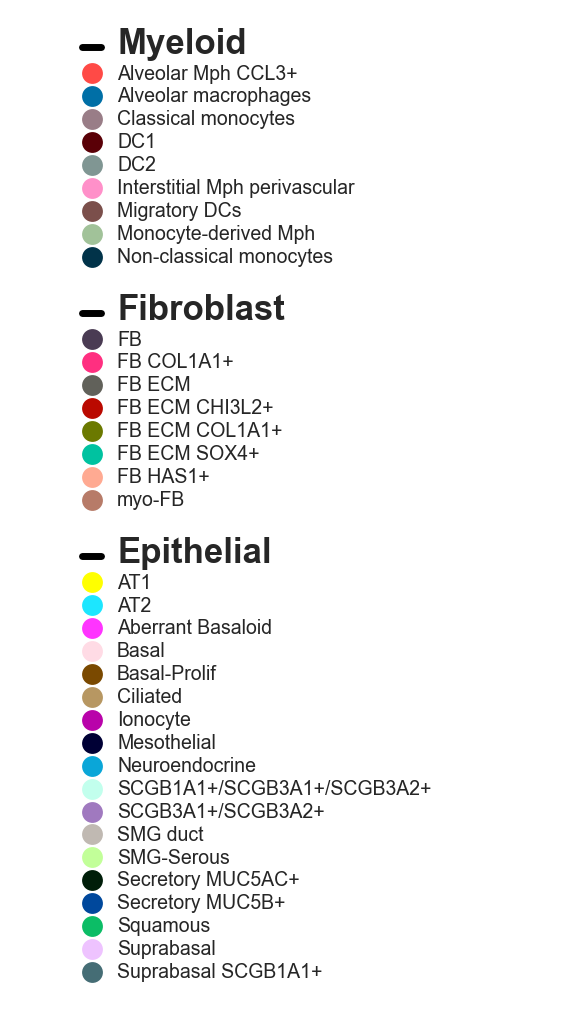

In [14]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

set_vis_default(font = 1.6, circle_marker = 3.)

fig, ax = plt.subplots(figsize = (7, 6))
ax.grid(False)
ax.axis('off')

handles = []
for ct_group, group_title in zip(ct_all, group_titles):
    ct_group = sorted(ct_group)
    handles.append(Line2D([0.5, .5], [0, 1], color='black', lw=5, label=group_title))  # Group title handle
    for label in ct_group:
        color = color_dict[label]
#         handles.append(Line2D([0], [0], color=color, lw=4, label=label))
        linewidth = 0.
        s, alpha = 5, 0.5
        linecolor = None

        handles.append(
            Line2D(
                [0], [0], marker='o', color='w', 
                label=label,
                markerfacecolor=color, 
                markersize=s, markeredgewidth=linewidth,
                markeredgecolor = linecolor,
            )
        )
    handles.append(Line2D([0], [0], color='white', lw=5, label=''))  # Group title handle

# Create the legend
legend = ax.legend(
    handles=handles, loc='upper left', 
    title='', bbox_to_anchor=(.1, 1), ncol = 1, 
    handlelength = 1., handleheight = .2, labelspacing = .2
)
for text in legend.get_texts():
    if text.get_text() in group_titles:  # Check if the text is a group title
        text.set_fontweight('bold')
        text.set_fontsize(25)


plt.show()
plt.close()